# Airline Delay Propagation Analysis — 01: Data Cleaning & EDA

**Dataset:** Kaggle — [`giovamata/airlinedelaycauses`](https://www.kaggle.com/datasets/giovamata/airlinedelaycauses)
("Airlines Delay" / `DelayedFlights.csv`) — U.S. DOT flight delay data for 2008, ~1.94M rows x 29 columns, ~250-280MB.

**Confirmed columns:** `Year, Month, DayofMonth, DayOfWeek, DepTime, CRSDepTime, ArrTime, CRSArrTime,
UniqueCarrier, FlightNum, TailNum, ActualElapsedTime, CRSElapsedTime, AirTime, ArrDelay, DepDelay, Origin,
Dest, Distance, TaxiIn, TaxiOut, Cancelled, CancellationCode, Diverted, CarrierDelay, WeatherDelay,
NASDelay, SecurityDelay, LateAircraftDelay`

This dataset has a genuine aircraft tail number (`TailNum`), so this notebook uses the **true**
aircraft-rotation propagation methodology (tracing each physical aircraft's sequence of flights across
the day) rather than the airport-level or delay-cause-only proxies needed for datasets without a tail
number.

**Getting the data into Colab** (pick one):
```python
# Option A: Kaggle API (recommended -- needs a kaggle.json API token, see kaggle.com/settings)
!pip install kaggle -q
from google.colab import files
files.upload()  # upload your kaggle.json when prompted
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d giovamata/airlinedelaycauses -p . --unzip
```
```python
# Option B: manual -- download DelayedFlights.csv from the Kaggle page above and upload it
# via the Colab file browser (folder icon on the left > upload icon)
```

This notebook:
1. Installs required libraries
2. Loads the raw dataset and verifies column names + row count
3. Cleans the data (missing values, duplicates, datetime conversion, cancelled-flight removal, outliers)
4. Creates the binary target `DEP_DEL15` (not present in the raw file -- this dataset predates that field)
5. Runs EDA with visualizations
6. Runs statistical tests (correlation, t-test, chi-square)
7. Exports `cleaned_flights.csv` for the SQL analysis notebook


## 1. Install & Import Libraries

In [1]:
!pip install duckdb -q
!pip install scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries loaded successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


## 2. Load Raw Dataset

See the download options in the intro cell above. This cell also supports working with a sample if memory is tight.

In [2]:
DATA_PATH = "/content/DelayedFlights.csv"
SAMPLE_ROWS = None   # e.g. 300_000 to work with a random sample instead of the full ~1.94M rows

try:
    if SAMPLE_ROWS is None:
        df_raw = pd.read_csv(DATA_PATH, low_memory=False)
    else:
        with open(DATA_PATH) as f:
            n_total = sum(1 for _ in f) - 1
        if n_total > SAMPLE_ROWS:
            import random
            random.seed(42)
            skip_rows = sorted(random.sample(range(1, n_total + 1), n_total - SAMPLE_ROWS))
            df_raw = pd.read_csv(DATA_PATH, skiprows=skip_rows, low_memory=False)
        else:
            df_raw = pd.read_csv(DATA_PATH, low_memory=False)
    print(f"Successfully loaded '{DATA_PATH}'" + (f" (sampled to {SAMPLE_ROWS:,} rows)" if SAMPLE_ROWS else ""))
    print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Download it from Kaggle (see the intro cell for two options) "
        f"and make sure the file is named 'DelayedFlights.csv' in this Colab session's working directory."
    )
except Exception as e:
    raise Exception(f"Unexpected error while loading data: {e}")

print("\n=== RAW COLUMN NAMES (verify these against the data dictionary) ===")
for i, c in enumerate(df_raw.columns):
    print(f"{i:2d}. {c}")


Successfully loaded '/content/DelayedFlights.csv'
Shape: 1,936,758 rows x 30 columns

=== RAW COLUMN NAMES (verify these against the data dictionary) ===
 0. Unnamed: 0
 1. Year
 2. Month
 3. DayofMonth
 4. DayOfWeek
 5. DepTime
 6. CRSDepTime
 7. ArrTime
 8. CRSArrTime
 9. UniqueCarrier
10. FlightNum
11. TailNum
12. ActualElapsedTime
13. CRSElapsedTime
14. AirTime
15. ArrDelay
16. DepDelay
17. Origin
18. Dest
19. Distance
20. TaxiIn
21. TaxiOut
22. Cancelled
23. CancellationCode
24. Diverted
25. CarrierDelay
26. WeatherDelay
27. NASDelay
28. SecurityDelay
29. LateAircraftDelay


In [3]:
print("=== First 5 rows ===")
display(df_raw.head())

print("\n=== Data types ===")
print(df_raw.dtypes)

print("\n=== Missing values per column ===")
print(df_raw.isnull().sum().sort_values(ascending=False))


=== First 5 rows ===


,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,...,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000,WN,...,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750,WN,...,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,...,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110,WN,...,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN



=== Data types ===
Unnamed: 0             int64
Year                   int64
Month                  int64
DayofMonth             int64
DayOfWeek              int64
DepTime              float64
CRSDepTime             int64
ArrTime              float64
CRSArrTime             int64
UniqueCarrier         object
FlightNum              int64
TailNum               object
ActualElapsedTime    float64
CRSElapsedTime       float64
AirTime              float64
ArrDelay             float64
DepDelay             float64
Origin                object
Dest                  object
Distance               int64
TaxiIn               float64
TaxiOut              float64
Cancelled              int64
CancellationCode      object
Diverted               int64
CarrierDelay         float64
WeatherDelay         float64
NASDelay             float64
SecurityDelay        float64
LateAircraftDelay    float64
dtype: object

=== Missing values per column ===
NASDelay             689270
CarrierDelay         689270
LateA

### Memory optimization

Downcasts numeric columns to the smallest dtype that safely holds their values. Typically cuts memory
usage by 40-60% with no loss of precision -- helpful given this file's ~1.94M rows.

In [4]:
def downcast_numeric(frame):
    before_mb = frame.memory_usage(deep=True).sum() / 1024**2
    for col in frame.select_dtypes(include=['int64']).columns:
        frame[col] = pd.to_numeric(frame[col], downcast='integer')
    for col in frame.select_dtypes(include=['float64']).columns:
        frame[col] = pd.to_numeric(frame[col], downcast='float')
    after_mb = frame.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {before_mb:.1f} MB -> {after_mb:.1f} MB ({(1 - after_mb/before_mb)*100:.1f}% reduction)")
    return frame

df_raw = downcast_numeric(df_raw)


Memory usage: 849.6 MB -> 618.8 MB (27.2% reduction)


## 3. Standardize Column Names

Lowercase, underscores, no leading/trailing spaces. Also builds `fl_date` from the separate Year/Month/DayofMonth columns (this dataset has no single date field).

In [5]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print("Standardized column names:")
print(list(df.columns))

EXPECTED = ['year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime', 'arrtime', 'crsarrtime',
            'uniquecarrier', 'flightnum', 'tailnum', 'actualelapsedtime', 'crselapsedtime', 'airtime',
            'arrdelay', 'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout', 'cancelled',
            'cancellationcode', 'diverted', 'carrierdelay', 'weatherdelay', 'nasdelay', 'securitydelay',
            'lateaircraftdelay']
missing_expected = [c for c in EXPECTED if c not in df.columns]
if missing_expected:
    print(f"\nWARNING: expected columns not found (steps using them will be skipped): {missing_expected}")
else:
    print("\nAll expected columns present.")

HAS_TAIL_NUM = 'tailnum' in df.columns
print(f"\nHas tailnum for true aircraft-rotation propagation tracing: {HAS_TAIL_NUM}")


Standardized column names:
['unnamed_0', 'year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime', 'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum', 'tailnum', 'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay', 'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout', 'cancelled', 'cancellationcode', 'diverted', 'carrierdelay', 'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay']

All expected columns present.

Has tailnum for true aircraft-rotation propagation tracing: True


## 4. Handle Missing Values

Delay-cause columns (`carrierdelay`, `weatherdelay`, `nasdelay`, `securitydelay`, `lateaircraftdelay`) are blank when a flight is not delayed, so blanks are filled with 0.

In [6]:
delay_cause_cols = ['carrierdelay', 'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay']
delay_cause_cols = [c for c in delay_cause_cols if c in df.columns]

for col in delay_cause_cols:
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(0)
    print(f"Filled {n_missing:,} missing values in '{col}' with 0")

print("\n=== Remaining missing values (non-zero only) ===")
remaining = df.isnull().sum()
print(remaining[remaining > 0].sort_values(ascending=False) if remaining.sum() > 0 else "None")


Filled 689,270 missing values in 'carrierdelay' with 0
Filled 689,270 missing values in 'weatherdelay' with 0
Filled 689,270 missing values in 'nasdelay' with 0
Filled 689,270 missing values in 'securitydelay' with 0
Filled 689,270 missing values in 'lateaircraftdelay' with 0

=== Remaining missing values (non-zero only) ===
actualelapsedtime    8387
airtime              8387
arrdelay             8387
arrtime              7110
taxiin               7110
taxiout               455
crselapsedtime        198
tailnum                 5
dtype: int64


## 5. Remove Duplicate Records

In [7]:
n_before = len(df)
subset_cols = [c for c in ['year', 'month', 'dayofmonth', 'uniquecarrier', 'flightnum', 'origin'] if c in df.columns]

df = df.drop_duplicates(subset=subset_cols if subset_cols else None, keep='first')
n_after = len(df)

print(f"Dedup key used: {subset_cols}")
print(f"Removed {n_before - n_after:,} duplicate records ({(n_before-n_after)/n_before*100:.2f}%)")
print(f"Remaining rows: {n_after:,}")


Dedup key used: ['year', 'month', 'dayofmonth', 'uniquecarrier', 'flightnum', 'origin']
Removed 2 duplicate records (0.00%)
Remaining rows: 1,936,756


## 6. Convert Date/Time Columns

This dataset has no single date field -- `fl_date` is built from `year`/`month`/`dayofmonth`. Time fields (`crsdeptime`, `deptime`, etc.) are stored as HHMM integers/floats and are converted to hour-of-day.

In [8]:
if all(c in df.columns for c in ['year', 'month', 'dayofmonth']):
    df['fl_date'] = pd.to_datetime(
        df[['year', 'month', 'dayofmonth']].rename(columns={'dayofmonth': 'day'}),
        errors='coerce'
    )
    n_bad = df['fl_date'].isnull().sum()
    if n_bad > 0:
        print(f"WARNING: {n_bad:,} rows had unparseable dates and were dropped")
        df = df.dropna(subset=['fl_date'])
    print(f"Built 'fl_date' from year/month/dayofmonth. Range: {df['fl_date'].min().date()} to {df['fl_date'].max().date()}")

DOW_MAP = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
if 'dayofweek' in df.columns:
    df['day_of_week'] = df['dayofweek'].map(DOW_MAP)
    print("Derived 'day_of_week' from 'dayofweek' (1=Monday ... 7=Sunday)")

def hhmm_to_hour(series):
    """Convert HHMM-style integer/float time columns (e.g. 1345.0) to hour-of-day (0-23)."""
    s = pd.to_numeric(series, errors='coerce')
    s = s.clip(lower=0, upper=2400)
    hour = (s // 100).clip(upper=23)
    return hour

for time_col, hour_col in [('crsdeptime', 'crs_dep_hour'), ('deptime', 'dep_hour'),
                            ('crsarrtime', 'crs_arr_hour'), ('arrtime', 'arr_hour')]:
    if time_col in df.columns:
        df[hour_col] = hhmm_to_hour(df[time_col])
        print(f"Derived '{hour_col}' from '{time_col}'")

print("\nSample of converted date/time fields:")
sample_cols = [c for c in ['fl_date', 'day_of_week', 'crs_dep_hour', 'dep_hour'] if c in df.columns]
display(df[sample_cols].head())


Built 'fl_date' from year/month/dayofmonth. Range: 2008-01-01 to 2008-12-31
Derived 'day_of_week' from 'dayofweek' (1=Monday ... 7=Sunday)
Derived 'crs_dep_hour' from 'crsdeptime'
Derived 'dep_hour' from 'deptime'
Derived 'crs_arr_hour' from 'crsarrtime'
Derived 'arr_hour' from 'arrtime'

Sample of converted date/time fields:


,fl_date,day_of_week,crs_dep_hour,dep_hour
0,2008-01-03,Thursday,19,20.0
1,2008-01-03,Thursday,7,7.0
2,2008-01-03,Thursday,6,6.0
3,2008-01-03,Thursday,17,18.0
4,2008-01-03,Thursday,19,19.0


## 7. Remove Cancelled Flights

Cancelled flights have no departure/arrival delay to measure and would distort propagation analysis.

In [9]:
if 'cancelled' in df.columns:
    n_before = len(df)
    df['cancelled'] = pd.to_numeric(df['cancelled'], errors='coerce').fillna(0)
    df = df[df['cancelled'] == 0].copy()
    n_after = len(df)
    print(f"Removed {n_before - n_after:,} cancelled flights ({(n_before-n_after)/n_before*100:.2f}%)")
else:
    print("No 'cancelled' column found; skipping this step.")

if 'diverted' in df.columns:
    n_before = len(df)
    df['diverted'] = pd.to_numeric(df['diverted'], errors='coerce').fillna(0)
    df = df[df['diverted'] == 0].copy()
    n_after = len(df)
    print(f"Removed {n_before - n_after:,} diverted flights ({(n_before-n_after)/max(n_before,1)*100:.2f}%)")

print(f"Remaining rows: {len(df):,}")


Removed 633 cancelled flights (0.03%)
Removed 7,754 diverted flights (0.40%)
Remaining rows: 1,928,369


## 8. Handle Outliers in Delay Columns

Delay minutes are capped using the IQR method (values beyond 3x IQR winsorized, not dropped) since extreme delays are real and analytically important for propagation analysis.

In [10]:
delay_value_cols = [c for c in ['depdelay', 'arrdelay'] if c in df.columns]

for col in delay_value_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = min(q1 - 3 * iqr, -60)
    upper_bound = q3 + 3 * iqr

    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"'{col}': capped {n_outliers:,} outlier values to [{lower_bound:.1f}, {upper_bound:.1f}] minutes")

before = len(df)
df = df.dropna(subset=delay_value_cols)
print(f"\nDropped {before - len(df):,} rows with unrecoverable missing delay values")
print(f"Final row count after outlier handling: {len(df):,}")


'depdelay': capped 55,356 outlier values to [-111.0, 176.0] minutes
'arrdelay': capped 44,570 outlier values to [-132.0, 197.0] minutes

Dropped 0 rows with unrecoverable missing delay values
Final row count after outlier handling: 1,928,369


## 9. Create Binary Target: `dep_del15`

This dataset predates the standard `DEP_DEL15` field, so it's created here: 1 if departure delay >= 15 minutes, else 0 (standard BTS on-time performance definition). Note: since this specific Kaggle file (`DelayedFlights.csv`) is pre-filtered to already-delayed flights, `dep_del15` will skew high here -- see the caveat in the report.

In [11]:
df['dep_del15'] = (df['depdelay'] >= 15).astype(int)

print("dep_del15 distribution:")
print(df['dep_del15'].value_counts())
print(f"\nDelay rate (>=15 min) within this (pre-filtered, delayed-flights-only) file: {df['dep_del15'].mean()*100:.2f}%")
print("Note: this file contains only flights that were already delayed/diverted/cancelled in the source "
      "extract, so this rate is NOT comparable to a system-wide OTP figure -- it measures severity "
      "*among delayed flights*, which is still useful for propagation analysis but should be labeled "
      "accordingly in any report.")


dep_del15 distribution:
dep_del15
1    1321154
0     607215
Name: count, dtype: int64

Delay rate (>=15 min) within this (pre-filtered, delayed-flights-only) file: 68.51%
Note: this file contains only flights that were already delayed/diverted/cancelled in the source extract, so this rate is NOT comparable to a system-wide OTP figure -- it measures severity *among delayed flights*, which is still useful for propagation analysis but should be labeled accordingly in any report.


## 10. Exploratory Data Analysis

### 10.1 Histogram of Departure Delays

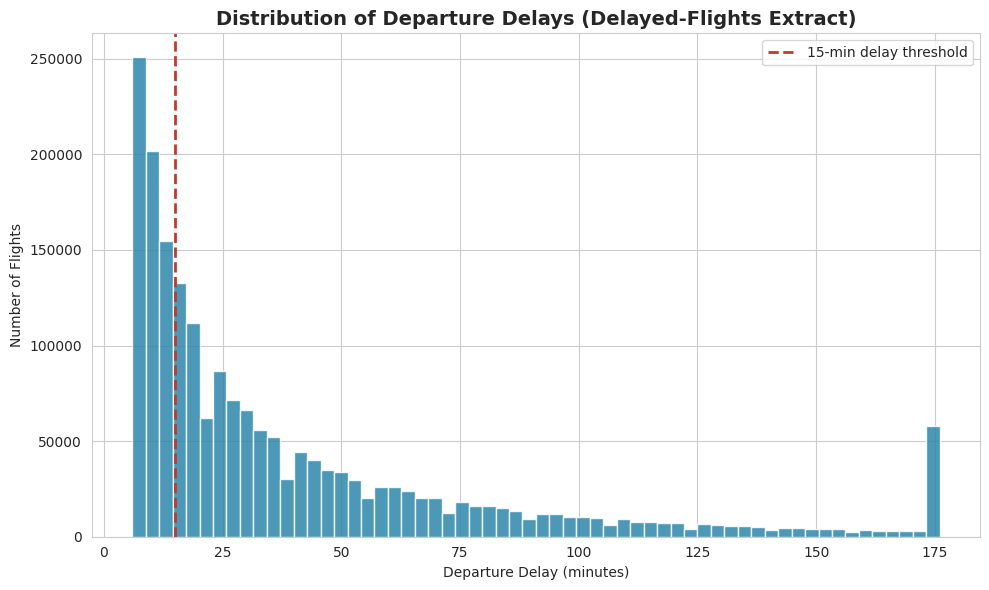

Median departure delay: 24.0 min
Mean departure delay: 40.9 min


In [12]:
plt.figure(figsize=(10, 6))
plot_data = df[df['depdelay'].between(-30, 300)]['depdelay']
plt.hist(plot_data, bins=60, color='#2E86AB', edgecolor='white', alpha=0.85)
plt.axvline(15, color='#C0392B', linestyle='--', linewidth=2, label='15-min delay threshold')
plt.title('Distribution of Departure Delays (Delayed-Flights Extract)', fontsize=14, fontweight='bold')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.legend()
plt.tight_layout()
plt.savefig('hist_dep_delay.png', dpi=120)
plt.show()

print(f"Median departure delay: {df['depdelay'].median():.1f} min")
print(f"Mean departure delay: {df['depdelay'].mean():.1f} min")


### 10.2 Delay Rate by Hour of Day

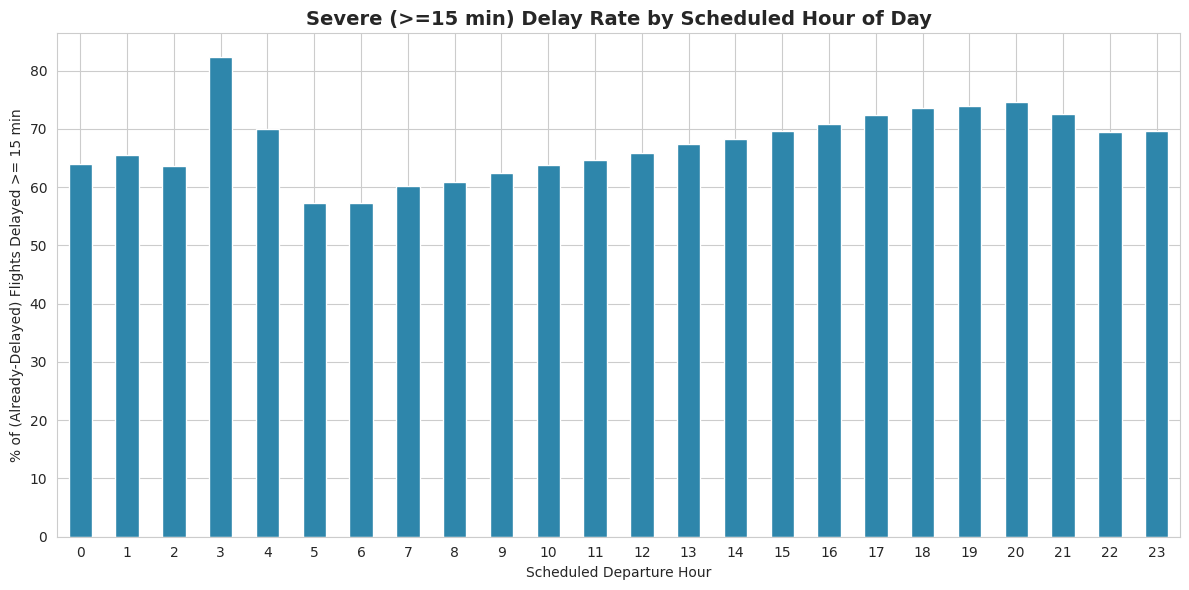

Highest-severity hours:
crs_dep_hour
3     82.307692
20    74.697163
19    73.989927
18    73.598439
21    72.535682
Name: dep_del15, dtype: float64


In [13]:
if 'crs_dep_hour' in df.columns:
    hourly_delay = df.groupby('crs_dep_hour')['dep_del15'].mean().sort_index() * 100

    plt.figure(figsize=(12, 6))
    hourly_delay.plot(kind='bar', color='#2E86AB', edgecolor='white')
    plt.title('Severe (>=15 min) Delay Rate by Scheduled Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Scheduled Departure Hour')
    plt.ylabel('% of (Already-Delayed) Flights Delayed >= 15 min')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('delay_by_hour.png', dpi=120)
    plt.show()

    print("Highest-severity hours:")
    print(hourly_delay.sort_values(ascending=False).head(5))
else:
    print("Skipped: 'crs_dep_hour' not available")


### 10.3 Delay Rate by Day of Week

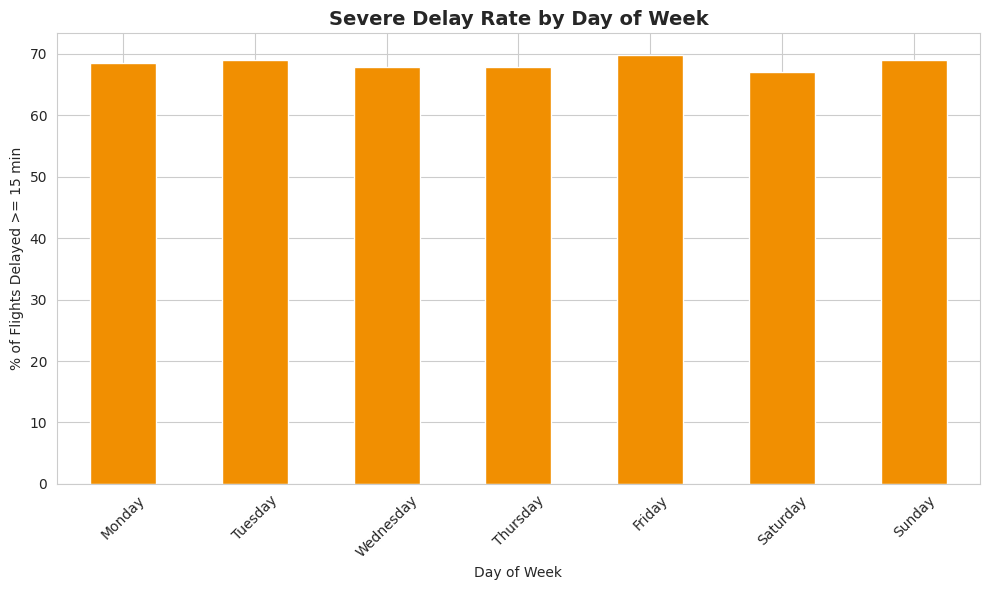

day_of_week
Monday       68.551387
Tuesday      68.927592
Wednesday    67.786369
Thursday     67.882931
Friday       69.837444
Saturday     67.046053
Sunday       69.037692
Name: dep_del15, dtype: float64


In [14]:
if 'day_of_week' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_delay = df.groupby('day_of_week')['dep_del15'].mean().reindex(day_order) * 100

    plt.figure(figsize=(10, 6))
    dow_delay.plot(kind='bar', color='#F18F01', edgecolor='white')
    plt.title('Severe Delay Rate by Day of Week', fontsize=14, fontweight='bold')
    plt.xlabel('Day of Week')
    plt.ylabel('% of Flights Delayed >= 15 min')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('delay_by_dow.png', dpi=120)
    plt.show()

    print(dow_delay)
else:
    print("Skipped: 'day_of_week' not available")


### 10.4 Correlation Heatmap

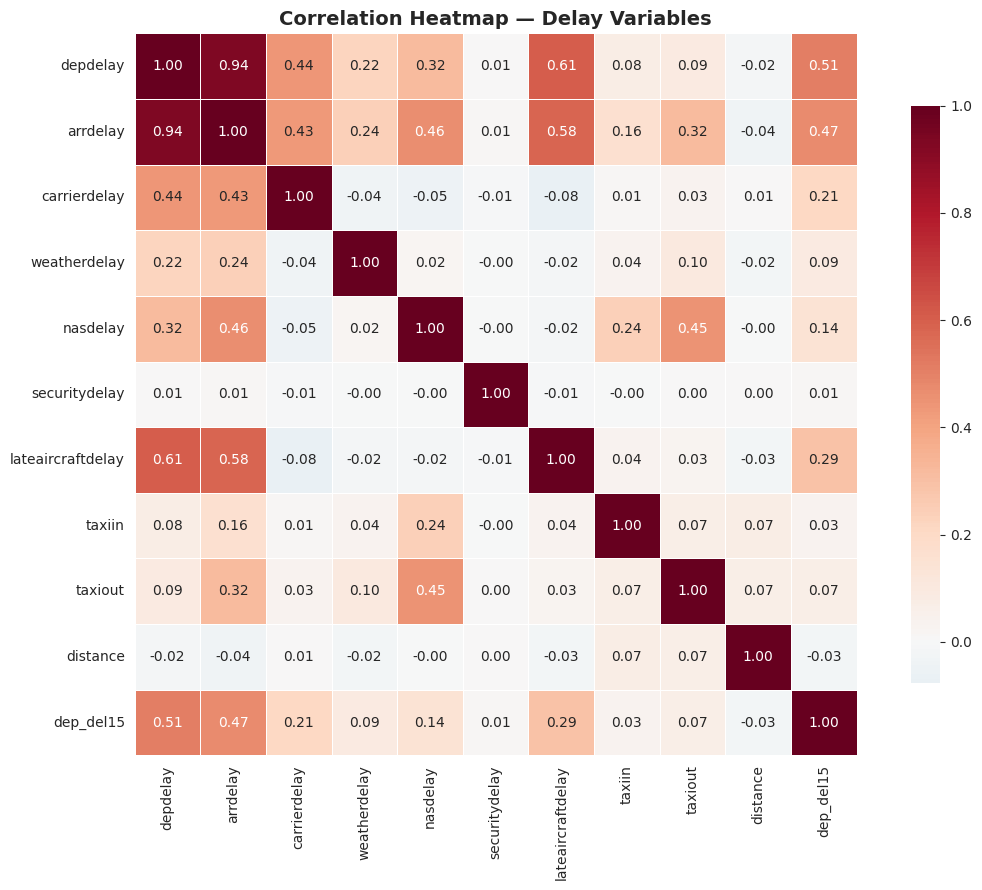

In [15]:
numeric_cols = [c for c in ['depdelay', 'arrdelay', 'carrierdelay', 'weatherdelay', 'nasdelay',
                             'securitydelay', 'lateaircraftdelay', 'taxiin', 'taxiout', 'distance',
                             'dep_del15'] if c in df.columns]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Delay Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


### 10.5 Box Plot: Delay by Carrier Type (LCC vs FSC)

Carriers present in this file:
uniquecarrier
WN    376201
AA    190910
MQ    141223
UA    140904
OO    131780
DL    113728
XE    103147
CO     99731
US     98007
EV     81762
NW     78843
FL     70969
YV     66769
B6     54925
OH     52453
9E     51569
AS     39010
F9     28222
HA      7472
AQ       744
Name: count, dtype: int64

carrier_type distribution:
carrier_type
FSC      768605
Other    684372
LCC      475392
Name: count, dtype: int64


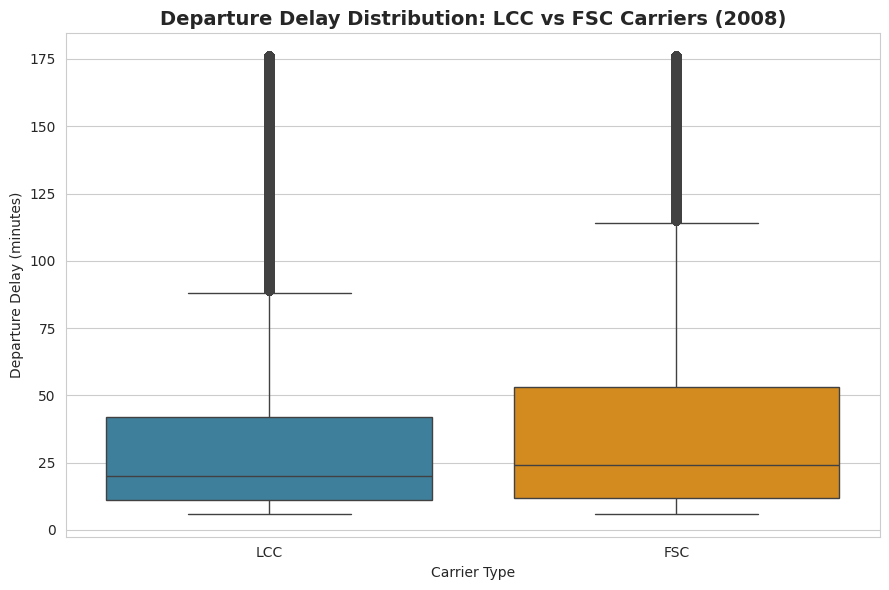

                 count       mean        std  min   25%   50%   75%    max
carrier_type                                                              
FSC           768605.0  40.928768  41.904568  6.0  12.0  24.0  53.0  176.0
LCC           475392.0  34.198456  36.320366  6.0  11.0  20.0  42.0  176.0
Other         684372.0  45.389717  44.194813  6.0  13.0  28.0  61.0  176.0


In [16]:
LCC_CARRIERS = {'WN', 'NK', 'F9', 'FL'}   # Southwest, Spirit, Frontier, AirTran (2008-era LCCs)
FSC_CARRIERS = {'AA', 'DL', 'UA', 'US', 'NW', 'CO', 'HA', 'AS'}  # American, Delta, United, US Airways, Northwest, Continental, Hawaiian, Alaska

if 'uniquecarrier' in df.columns:
    print("Carriers present in this file:")
    print(df['uniquecarrier'].value_counts())

    df['carrier_type'] = np.where(df['uniquecarrier'].isin(LCC_CARRIERS), 'LCC',
                          np.where(df['uniquecarrier'].isin(FSC_CARRIERS), 'FSC', 'Other'))

    print("\ncarrier_type distribution:")
    print(df['carrier_type'].value_counts())

    plot_df = df[df['carrier_type'].isin(['LCC', 'FSC']) & df['depdelay'].between(-30, 200)]

    if plot_df['carrier_type'].nunique() == 2:
        plt.figure(figsize=(9, 6))
        sns.boxplot(data=plot_df, x='carrier_type', y='depdelay', palette=['#2E86AB', '#F18F01'])
        plt.title('Departure Delay Distribution: LCC vs FSC Carriers (2008)', fontsize=14, fontweight='bold')
        plt.xlabel('Carrier Type')
        plt.ylabel('Departure Delay (minutes)')
        plt.tight_layout()
        plt.savefig('boxplot_carrier_type.png', dpi=120)
        plt.show()
        print(df.groupby('carrier_type')['depdelay'].describe())
    else:
        print("WARNING: fewer than 2 carrier types classified as LCC/FSC -- check uniquecarrier codes above.")
else:
    print("Skipped: 'uniquecarrier' not available")


## 11. Statistical Analysis

### 11.1 Correlation: Previous Arrival Delay vs Current Departure Delay

Using each aircraft's (`tailnum`) flight sequence, we compute the delay of its *previous* arrival and correlate it with the *current* flight's departure delay — the core signal behind delay propagation. This is the true aircraft-rotation methodology, possible here because this dataset has a real tail number.

In [17]:
if 'tailnum' in df.columns:
    df_sorted = df.sort_values(['tailnum', 'fl_date', 'crsdeptime']).copy()
    df_sorted['prev_arr_delay'] = df_sorted.groupby('tailnum')['arrdelay'].shift(1)

    valid = df_sorted.dropna(subset=['prev_arr_delay', 'depdelay'])
    r, p_value = stats.pearsonr(valid['prev_arr_delay'], valid['depdelay'])

    print(f"Pearson correlation (previous arrival delay -> current departure delay): r = {r:.4f}")
    print(f"P-value: {p_value:.2e}")
    print(f"Interpretation: {'Statistically significant' if p_value < 0.05 else 'Not statistically significant'} "
          f"{'positive' if r > 0 else 'negative'} relationship, n = {len(valid):,}")

    df = df_sorted
else:
    print("Skipped: requires 'tailnum'")


Pearson correlation (previous arrival delay -> current departure delay): r = 0.4224
P-value: 0.00e+00
Interpretation: Statistically significant positive relationship, n = 1,923,006


### 11.2 T-Test: LCC vs FSC Propagation Exposure

Comparing mean departure delay between LCC and FSC carriers using an independent-samples (Welch's) t-test.

In [18]:
if 'carrier_type' in df.columns:
    lcc_delays = df.loc[df['carrier_type'] == 'LCC', 'depdelay'].dropna()
    fsc_delays = df.loc[df['carrier_type'] == 'FSC', 'depdelay'].dropna()

    if len(lcc_delays) > 1 and len(fsc_delays) > 1:
        t_stat, p_value = stats.ttest_ind(lcc_delays, fsc_delays, equal_var=False)
        print(f"LCC mean departure delay: {lcc_delays.mean():.2f} min (n={len(lcc_delays):,})")
        print(f"FSC mean departure delay: {fsc_delays.mean():.2f} min (n={len(fsc_delays):,})")
        print(f"\nWelch's t-test: t = {t_stat:.4f}, p = {p_value:.2e}")
        print(f"Result: {'Statistically significant difference' if p_value < 0.05 else 'No statistically significant difference'} "
              f"between LCC and FSC delay exposure (alpha = 0.05)")
    else:
        print("Not enough data in one of the LCC/FSC groups -- check carrier classification.")
else:
    print("Skipped: 'carrier_type' not available")


LCC mean departure delay: 34.20 min (n=475,392)
FSC mean departure delay: 40.93 min (n=768,605)

Welch's t-test: t = -94.6074, p = 0.00e+00
Result: Statistically significant difference between LCC and FSC delay exposure (alpha = 0.05)


### 11.3 Chi-Square Test: Weather-Caused Delay vs Propagation Flag

This dataset has no raw meteorological columns (temperature/precipitation), only the `weatherdelay` cause-code minutes. `propagation_flag` = 1 when the previous aircraft arrived >=15 min late AND the current flight is also delayed >=15 min. This is tested against whether the flight had any weather-attributed delay minutes.

In [19]:
if 'prev_arr_delay' in df.columns and 'weatherdelay' in df.columns:
    df['propagation_flag'] = ((df['prev_arr_delay'] >= 15) & (df['dep_del15'] == 1)).astype(int)
    df['had_weather_delay'] = (df['weatherdelay'] > 0).astype(int)

    contingency = pd.crosstab(df['had_weather_delay'], df['propagation_flag'])
    print("Contingency table (rows: had_weather_delay, cols: propagation_flag):")
    print(contingency)

    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    print(f"\nChi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"P-value: {p_value:.2e}")
    print(f"Result: {'Statistically significant association' if p_value < 0.05 else 'No statistically significant association'} "
          f"between weather-caused delay and propagation events (alpha = 0.05)")
else:
    print("Skipped: requires 'prev_arr_delay' and 'weatherdelay'")


Contingency table (rows: had_weather_delay, cols: propagation_flag):
propagation_flag        0       1
had_weather_delay                
0                  938321  891130
1                   31672   67246

Chi-square statistic: 13940.5718
Degrees of freedom: 1
P-value: 0.00e+00
Result: Statistically significant association between weather-caused delay and propagation events (alpha = 0.05)


## 12. Export Cleaned Data

In [20]:
output_path = 'cleaned_flights.csv'
try:
    df.to_csv(output_path, index=False)
    print(f"Exported cleaned dataset to '{output_path}'")
    print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
except Exception as e:
    raise Exception(f"Failed to export cleaned data: {e}")


Exported cleaned dataset to 'cleaned_flights.csv'
Final shape: 1,928,369 rows x 41 columns


## 13. Summary of Cleaning Steps & Findings

In [21]:
print("=" * 70)
print("DATA CLEANING & EDA SUMMARY")
print("=" * 70)
print(f"""
1. Column names standardized to lowercase/underscore format.
2. Missing values in delay-cause columns filled with 0 (not applicable).
3. Duplicate flight records removed based on date/carrier/flight number/route.
4. 'fl_date' built from year/month/dayofmonth (no single date column in source);
   time fields converted to hour-of-day.
5. Cancelled and diverted flights removed.
6. Outliers in delay columns capped using the IQR method (winsorized, not dropped).
7. Binary target 'dep_del15' created (1 if departure delay >= 15 min). NOTE: this
   Kaggle extract is pre-filtered to already-delayed/diverted/cancelled flights, so
   this rate reflects severity among delayed flights, not system-wide OTP.
8. EDA completed: delay distribution, delay by hour, delay by day of week,
   correlation heatmap, and LCC vs FSC delay boxplot.
9. Statistical tests completed using the TRUE aircraft-rotation methodology
   (this dataset has a real tailnum):
   - Pearson correlation between previous arrival delay and current departure delay
   - Welch's t-test comparing LCC vs FSC delay exposure
   - Chi-square test for weather-caused delay vs propagation flag
10. Final cleaned dataset exported to 'cleaned_flights.csv' for use in 02_sql_analysis.ipynb.

Final row count: {len(df):,}
Severe delay rate within this delayed-flights extract: {df['dep_del15'].mean()*100:.2f}%
""")


DATA CLEANING & EDA SUMMARY

1. Column names standardized to lowercase/underscore format.
2. Missing values in delay-cause columns filled with 0 (not applicable).
3. Duplicate flight records removed based on date/carrier/flight number/route.
4. 'fl_date' built from year/month/dayofmonth (no single date column in source);
   time fields converted to hour-of-day.
5. Cancelled and diverted flights removed.
6. Outliers in delay columns capped using the IQR method (winsorized, not dropped).
7. Binary target 'dep_del15' created (1 if departure delay >= 15 min). NOTE: this
   Kaggle extract is pre-filtered to already-delayed/diverted/cancelled flights, so
   this rate reflects severity among delayed flights, not system-wide OTP.
8. EDA completed: delay distribution, delay by hour, delay by day of week,
   correlation heatmap, and LCC vs FSC delay boxplot.
9. Statistical tests completed using the TRUE aircraft-rotation methodology
   (this dataset has a real tailnum):
   - Pearson correlation 